<a href="https://colab.research.google.com/github/Samar97adel/Machine-learning/blob/main/Regression_sklearn_Linear_Polynomial_Ridge_Lasso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

california_data = fetch_california_housing()

df = pd.DataFrame(california_data.data, columns=california_data.feature_names)
df['price'] = california_data.target
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
price,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [ ]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
price,0


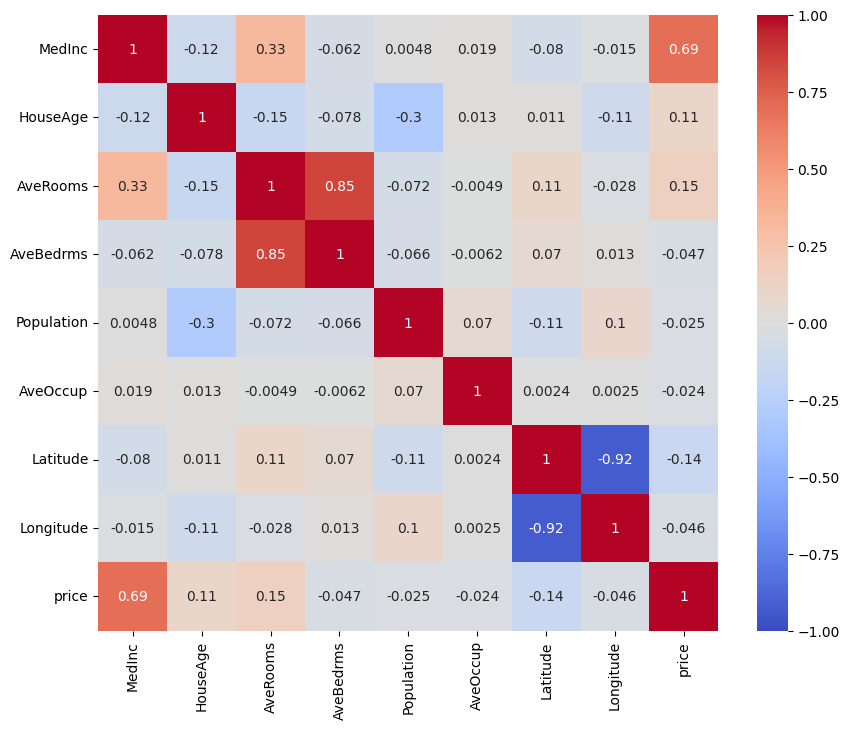

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

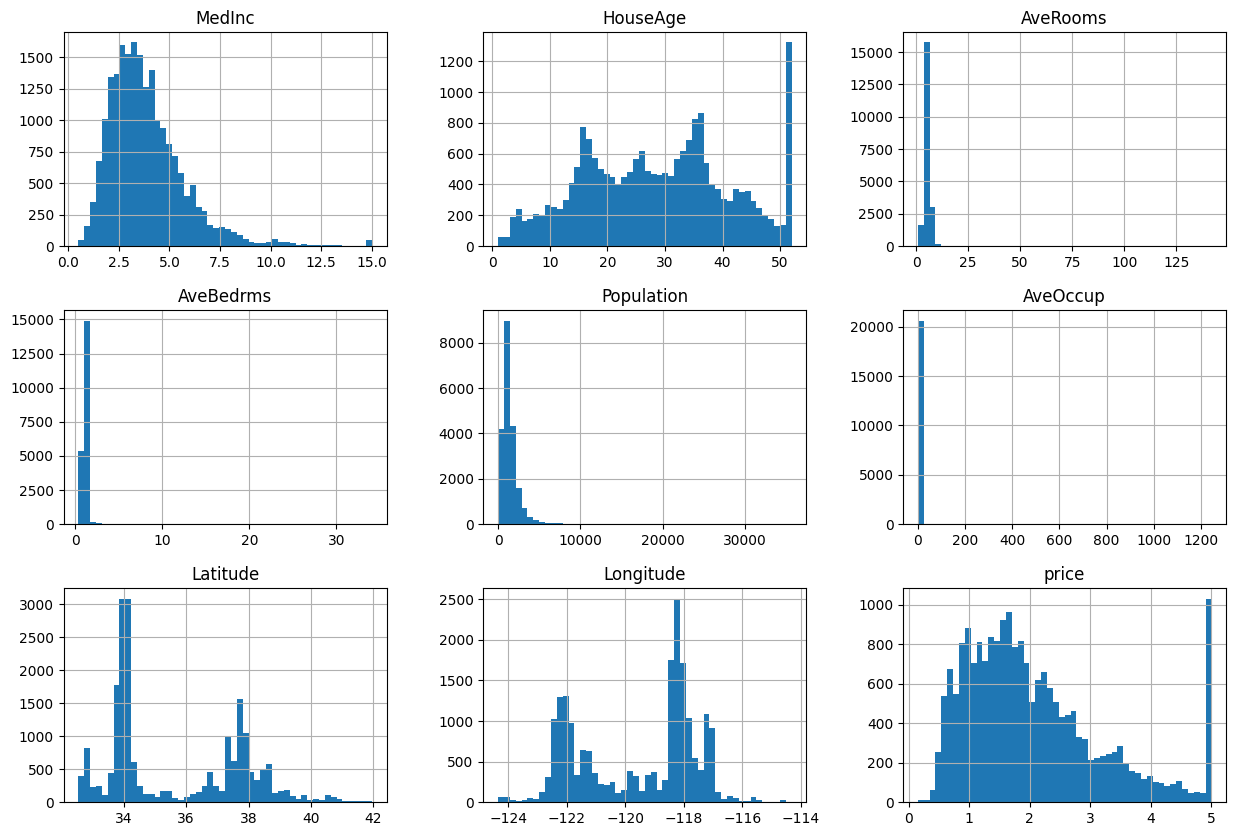

In [ ]:
df.hist(figsize=(15, 10), bins=50)
plt.show()

In [ ]:
X = df.drop('price', axis=1) # X = df.iloc[:, :-1]
y = df['price']

In [ ]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [ ]:
y

,price
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [ ]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
model_lr.coef_

array([ 4.48674910e-01,  9.72425752e-03, -1.23323343e-01,  7.83144907e-01,
       -2.02962058e-06, -3.52631849e-03, -4.19792487e-01, -4.33708065e-01])

In [ ]:
model_lr.intercept_

np.float64(-37.02327770606409)

In [ ]:
y_pred_lr = model_lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f'MSE: {mse_lr}')
print(f'MAE: {mae_lr}')

MSE: 0.5558915986952444
MAE: 0.5332001304956553


In [ ]:
from sklearn.linear_model import SGDRegressor

model = SGDRegressor(
    max_iter=1000,
    eta0=0.01,
    learning_rate="constant", #invscaling, adaptive
    tol=1e-3,
    random_state=42
)

model.fit(X_train, y_train)

SGDRegressor(learning_rate='constant', random_state=42)

In [ ]:
y_pred_sgd = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_sgd = mean_squared_error(y_test, y_pred_sgd)
mae_sgd = mean_absolute_error(y_test, y_pred_sgd)

print(f'MSE: {mse_sgd}')
print(f'MAE: {mae_sgd}')

MSE: 1.7894503017584798e+31
MAE: 2882423958496930.0


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

LinearRegression()

In [ ]:
y_pred_poly = model_poly.predict(X_test_poly)
print(f'MSE: {mean_squared_error(y_test, y_pred_poly)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_poly)}')

MSE: 0.4643015261571134
MAE: 0.4670009333449118


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_pred_poly = model_poly.predict(X_test_poly)
print(f'MSE: {mean_squared_error(y_test, y_pred_poly)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_poly)}')

MSE: 0.4643015261571134
MAE: 0.4670009333449118


In [ ]:
mse_poly = mean_squared_error(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)

print(f'MSE: {mse_poly}')
print(f'MAE: {mae_poly}')

MSE: 0.4643015261571134
MAE: 0.4670009333449118


# Ridge

In [ ]:
from sklearn.linear_model import Ridge

model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)
model_pred_ridge = model_ridge.predict(X_test)
print(f'MSE: {mean_squared_error(y_test, model_pred_ridge)}')
print(f'MAE: {mean_absolute_error(y_test, model_pred_ridge)}')

MSE: 0.5558034669932211
MAE: 0.5332039182571153


In [ ]:
mse_ridge_linear = mean_squared_error(y_test, model_pred_ridge)
mae_ridge_linear = mean_absolute_error(y_test, model_pred_ridge)

print(f'MSE: {mse_ridge_linear}')
print(f'MAE: {mae_ridge_linear}')

MSE: 0.5558034669932211
MAE: 0.5332039182571153


In [ ]:
from sklearn.linear_model import Ridge

model_ridge_poly = Ridge(alpha=1.0)
model_ridge_poly.fit(X_train_poly, y_train)
model_ridge_poly_predict = model_ridge_poly.predict(X_test_poly)
print(f'MSE: {mean_squared_error(y_test, model_ridge_poly_predict)}')
print(f'MAE: {mean_absolute_error(y_test, model_ridge_poly_predict)}')

MSE: 0.44227531996493163
MAE: 0.47154239506306056


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.54219e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [ ]:
mse_ridge_poly = mean_squared_error(y_test, model_ridge_poly_predict)
mae_ridge_poly = mean_absolute_error(y_test, model_ridge_poly_predict)

print(f'MSE: {mse_ridge_poly}')
print(f'MAE: {mae_ridge_poly}')

MSE: 0.44227531996493163
MAE: 0.47154239506306056


In [ ]:
from sklearn.linear_model import Lasso

model_lasso = Lasso(alpha=0.1)
model_lasso.fit(X_train, y_train)
model_pred_lasso = model_lasso.predict(X_test)
print(f'MSE: {mean_squared_error(y_test, model_pred_lasso)}')
print(f'MAE: {mean_absolute_error(y_test, model_pred_lasso)}')

MSE: 0.6135115198058131
MAE: 0.5816074623949868


In [ ]:
mse_lasso_linear = mean_squared_error(y_test, model_pred_lasso)
mae_lasso_linear = mean_absolute_error(y_test, model_pred_lasso)

print(f'MSE: {mse_lasso_linear}')
print(f'MAE: {mae_lasso_linear}')

MSE: 0.6135115198058131
MAE: 0.5816074623949868


In [ ]:
from sklearn.linear_model import Lasso

model_lasso_poly = Lasso(alpha=0.02)
model_lasso_poly.fit(X_train_poly, y_train)
model_pred_lasso_poly = model_lasso_poly.predict(X_test_poly)
print(f'MSE: {mean_squared_error(y_test, model_pred_lasso_poly)}')
print(f'MAE: {mean_absolute_error(y_test, model_pred_lasso_poly)}')

MSE: 0.4744513593936485
MAE: 0.501588618090341


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.887e+03, tolerance: 2.207e+00
  model = cd_fast.enet_coordinate_descent(


In [ ]:
mse_lasso_poly = mean_squared_error(y_test, model_pred_lasso_poly)
mae_lasso_poly = mean_absolute_error(y_test, model_pred_lasso_poly)

print(f'MSE: {mse_lasso_poly}')
print(f'MAE: {mae_lasso_poly}')

MSE: 0.4744513593936485
MAE: 0.501588618090341


In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'SGD', 'Polynomial Regression', 'Ridge Linear', 'Ridge Polynomia', 'Lasso Linear', 'Lasso Polynomia'],
    'MSE': [mse_lr, mse_sgd, mse_poly, mse_ridge_linear, mse_ridge_poly, mse_lasso_linear, mse_lasso_poly],
    'MAE': [mae_lr, mae_sgd, mae_poly, mae_ridge_linear, mae_ridge_poly, mae_lasso_linear, mae_lasso_poly]
})
results

,Model,MSE,MAE
0,Linear Regression,5.558916e-01,5.332001e-01
1,SGD,1.789450e+31,2.882424e+15
2,Polynomial Regression,4.643015e-01,4.670009e-01
3,Ridge Linear,5.558035e-01,5.332039e-01
4,Ridge Polynomia,4.422753e-01,4.715424e-01
5,Lasso Linear,6.135115e-01,5.816075e-01
6,Lasso Polynomia,4.744514e-01,5.015886e-01
